In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

survey_preferences = pd.read_csv("survey_preferences.csv")
brand_weights = pd.read_csv("brand_weights.csv")
car_ratings = pd.read_csv("car_ratings.csv")

from IPython.display import display
display(survey_preferences)
display(brand_weights)
display(car_ratings)

,Parameter,Rating(out of 10)
0,Safety,8.5
1,Fuel Efficiency,8.0
2,Maintainability,7.5
3,Durability,7.5
4,Manoeuvrability,7.0
5,Cost,6.5
6,Aesthetics,6.5


,Unnamed: 0,Comparison Matrix SUM(T+1); T=Total,Unnamed: 2,Unnamed: 3
0,Parameter,Tata,Maruti,Kia
1,Safety,16,15,13
2,Fuel Efficiency,8,9,8
3,Maintainability,11,10,7
4,Durability,10,9,8
5,Manoeuvrability,4,4,4
6,Cost,2,2,3
7,Aesthetics,1,1,1


,Car,Brand,Safety,Fuel Efficiency,Maintainability,Durability,Manoeuvrability,Cost,Aesthetics
0,Tata Nexon,Tata,9.0,7.0,8.0,7.50,7.0,7,7.5
1,Tata Altroz,Tata,8.5,8.0,7.5,8.00,8.0,8,8.0
2,Tata Tigor,Tata,7.0,7.5,7.0,7.00,7.5,8,6.5
3,Maruti Grand Vitara,Maruti,7.0,7.0,8.0,8.00,7.0,7,8.0
4,Maruti Breeza,Maruti,8.0,8.0,8.0,8.00,8.0,8,8.0
5,Maruti Ciaz,Maruti,6.0,9.0,9.0,9.00,8.0,8,7.0
6,Kia Sonet,Kia,7.0,7.5,8.0,8.00,8.0,8,7.5
7,Kia Carens,Kia,8.0,7.0,7.5,7.80,7.0,7,8.5
8,Kia Seltos,Kia,8.5,6.0,7.5,7.75,6.5,6,8.0


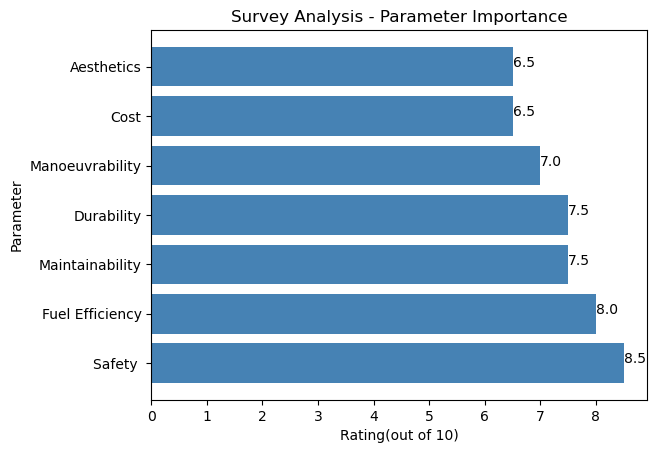

In [ ]:
#Section 2 - Survey Analysis
#Visualizing how 47 respondents rated each parameter out of 10
#Using horizontal bar chart - parameters on Y axis, ratings on X axis

import matplotlib.pyplot as plt

survey_preferences = pd.read_csv("survey_preferences.csv")

parameter = survey_preferences["Parameter"]
rating = survey_preferences["Rating(out of 10)"]

#Plotting the bar chart
plt.xlabel("Rating(out of 10)")
plt.ylabel("Parameter")
plt.barh(parameter, rating, color='steelblue')
plt.title("Survey Analysis - Parameter Importance")

#add value labels to each bar
for index, value in enumerate(rating):
    plt.text(value, index, str(value))

plt.show()

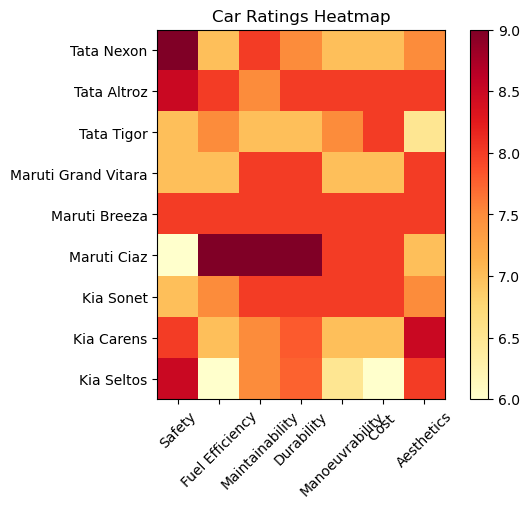

In [12]:
#Section 3 - Car Ratings Heatmap
#Dark red = high ratiing, Light Yellow = low rating

#Extract only numeric columns (drop Car and Brand)
numeric_data = car_ratings.select_dtypes(include = 'number')

#X axis - parameter names, Y axis - car names
plt.xticks(range(len(numeric_data.columns)), numeric_data.columns, rotation=45)
plt.yticks(range(len(car_ratings)), car_ratings["Car"])

#Plot the heatmap
plt.imshow( numeric_data, cmap = 'YlOrRd')

#Add colour scale on the side
plt.colorbar()

plt.title("Car Ratings Heatmap")
plt.show()

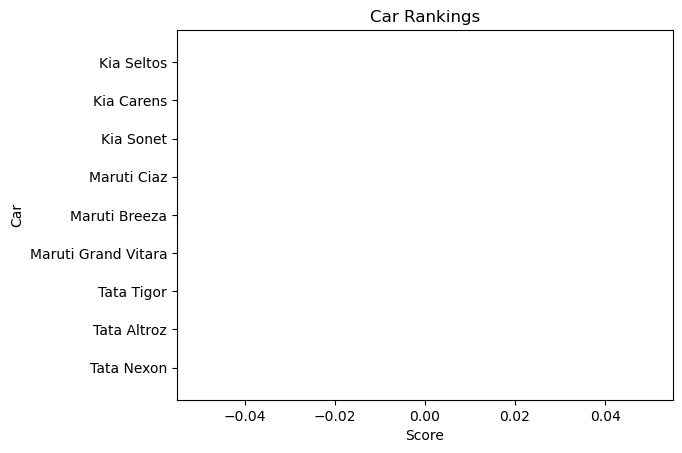

In [20]:
numeric_data = car_ratings.select_dtypes(include = 'number')
weights = brand_weights.select_dtypes(include = 'number')

weighted = numeric_data * weights

#sum each row(axis=1 means sum across columns(row by row))
final_scores = weighted.sum(axis=1)

result = pd.DataFrame({
    "Car" : car_ratings["Car"], 
    "Score"  : final_scores
})

results = result.sort_values("Score", ascending=False)
plt.barh(results["Car"], results["Score"], color = 'pink')
plt.xlabel("Score")
plt.ylabel("Car")

plt.title("Car Rankings")
plt.show()



